In [ ]:
import pandas as pd


df = pd.read_csv("./exp-branches.csv")
df = df[~df["hparams.branch_hparams.retrain_d.subset_file"].isna()]
df["subset_file"] = df["hparams.branch_hparams.retrain_d.subset_file"].apply(lambda x: x.split("/")[-1][:-4])
df["subset_avg"] = df["subset_file"].apply(lambda x: "_avg" in x)
df["subset_fraction"] = df["subset_file"].apply(lambda x: float(x.split("_")[2].split("-")[0]))
def get_offset(x):
    items = x.split("_")[2].split("-")
    if len(items) == 1:
        return 1 - float(items[0])
    return float(items[1])
df["subset_offset"] = df["subset_file"].apply(lambda x: get_offset(x))
df

<AxesSubplot:xlabel='subset_fraction', ylabel='test_accuracy'>

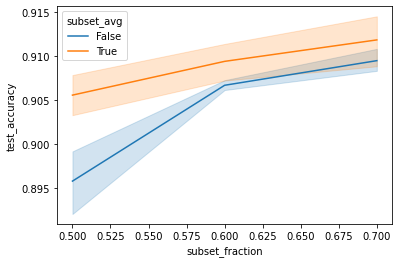

In [10]:
fig1 = df[df["subset_fraction"] != 0.1]
import seaborn as sns

sns.lineplot(data=fig1, x="subset_fraction", y="test_accuracy", hue="subset_avg")

<AxesSubplot:xlabel='subset_offset', ylabel='test_accuracy'>

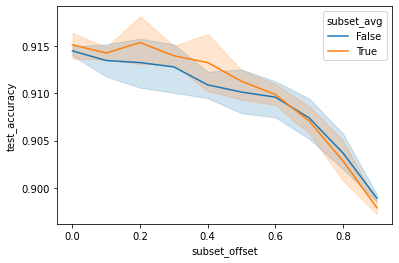

In [12]:
fig2 = df[df["subset_fraction"] == 0.1]

sns.lineplot(data=fig2, x="subset_offset", y="test_accuracy", hue="subset_avg")